In [1]:
import esigmapy
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

No version information file '.version' found


In [2]:
mean_anomaly_array = np.linspace(-np.pi, np.pi, 50)

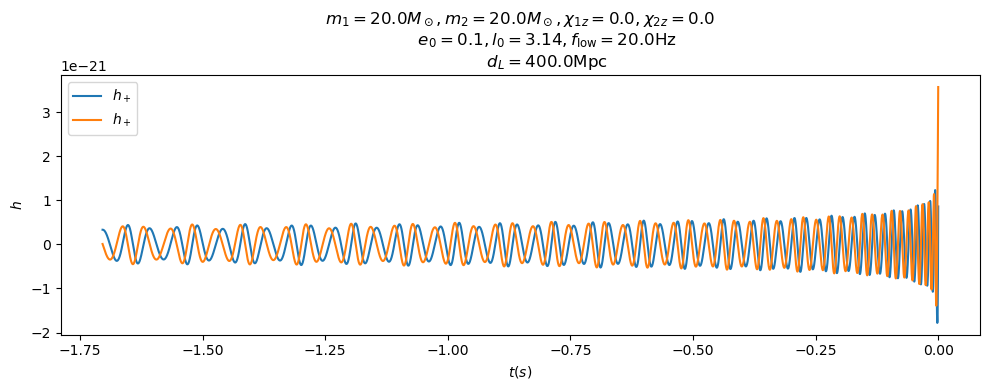

In [44]:
m1 = 20.
m2 = 20.
spin1z = 0.0
spin2z = 0.0
eccentricity = 0.1
mean_anomaly = np.pi
modes_to_use = [(2,2)]

distance = 400.

f_low = 20. 
delta_t = 1/2**14

orb_vars, ref_mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                        mass2=m2,
                                        spin1z=spin1z, 
                                        spin2z=spin2z,
                                        eccentricity=eccentricity,
                                        mean_anomaly=mean_anomaly,
                                        distance=distance,
                                        f_lower=f_low,
                                        delta_t=delta_t,
                                        include_conjugate_modes=False,
                                        modes_to_use=modes_to_use,
                                        return_orbital_params=['x'])

ref_signal = ref_mode[(2,2)]

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}$""")
ref_signal.plot(label=r"$h_+$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

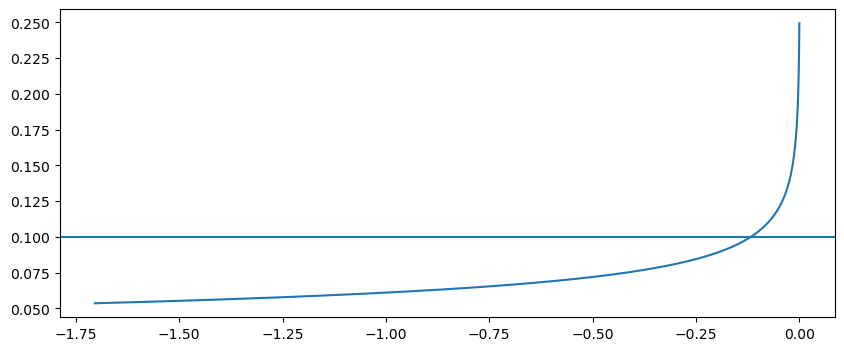

In [45]:
plt.figure(figsize=(10,4))
orb_vars['x'].plot()
plt.axhline(0.1)

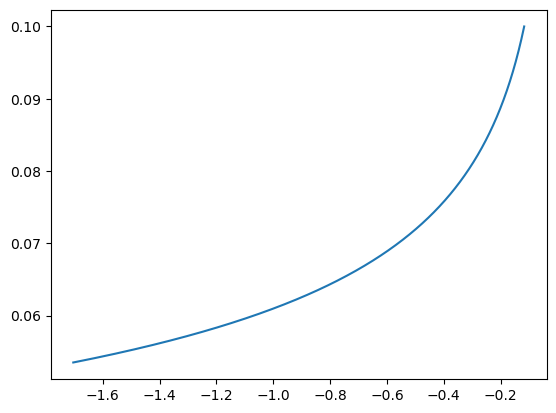

In [46]:
t_of_x_spline = CubicSpline(orb_vars['x'].data, orb_vars['x'].sample_times)

x_val = np.linspace(orb_vars['x'].data.min(), 0.1, 1000)

t_val = t_of_x_spline(x_val)

plt.plot(t_val, x_val)

In [51]:
ref_time = list(ref_signal.sample_times)

X_waveform = np.zeros((len(mean_anomaly_array), len(t_val)), dtype=complex)

for i, mean_anomaly in enumerate(mean_anomaly_array):
    orb_vars_test, test_modes = esigmapy.get_inspiral_esigma_modes(
        mass1=m1, mass2=m2,
        spin1z=spin1z, spin2z=spin2z,
        eccentricity=eccentricity, mean_anomaly=mean_anomaly,
        distance=distance,
        f_lower=f_low, delta_t=delta_t,
        modes_to_use=modes_to_use,
        return_orbital_params=['x']
    )
    
    signal = test_modes[(2,2)]

    x_test = orb_vars_test['x']
    t_of_x_spline = CubicSpline(x_test.data, x_test.sample_times)
    x_test_reconstructed = np.linspace(x_test.min(), 0.1, 1000)

    test_time = list(signal.sample_times)
    test_time_reconstructed = t_of_x_spline(x_test_reconstructed)

    signal_amp = np.abs(signal)
    signal_phase = np.unwrap(np.angle(signal))
    
    amp_spline = CubicSpline(test_time, signal_amp)
    test_sample_amp = amp_spline(test_time_reconstructed)
    phase_spline = CubicSpline(test_time, signal_phase)
    test_sample_phase = phase_spline(test_time_reconstructed)
    
    amp_spline = CubicSpline(test_time_reconstructed, test_sample_amp)
    test_sample_amp = amp_spline(t_val)
    phase_spline = CubicSpline(test_time_reconstructed, test_sample_phase)
    test_sample_phase = phase_spline(t_val)
    
    test_sample_phase = test_sample_phase - test_sample_phase[0]

    test_sample_aligned = test_sample_amp * np.exp(1j * test_sample_phase)
    
    X_waveform[i, :] = test_sample_aligned

In [52]:
U, s, Vt = np.linalg.svd(X_waveform, full_matrices=False)

In [53]:
eccentric_harmonics = {}
indices = np.arange(10)
indices = np.delete(indices, 2)
indices

array([0, 1, 3, 4, 5, 6, 7, 8, 9])

In [54]:
eccentric_harmonics = {}

waveform_j2 = s[0] * Vt[0]
phase_j2 = np.unwrap(np.angle(waveform_j2))
dt = np.abs(ref_time[1] - ref_time[0])
freq_22_2 = np.gradient(phase_j2, dt) / np.pi
f_orb = 0.5 * freq_22_2

eccentric_harmonics[2] = waveform_j2

num_bases_to_check = 10
for i in range(1, num_bases_to_check):
    waveform = s[i] * Vt[i]
    phase = np.unwrap(np.angle(waveform))
    freq_22_j = np.gradient(phase, dt) / np.pi

    j_index = round(freq_22_j[0] / f_orb[0])

    if j_index > 0 and j_index not in eccentric_harmonics:
        print(f"SVD basis i={i} corresponds to harmonic j={j_index}")
        eccentric_harmonics[j_index] = waveform

sorted_harmonics = dict(sorted(eccentric_harmonics.items()))

SVD basis i=1 corresponds to harmonic j=3
SVD basis i=2 corresponds to harmonic j=1
SVD basis i=3 corresponds to harmonic j=4
SVD basis i=4 corresponds to harmonic j=5
SVD basis i=9 corresponds to harmonic j=6


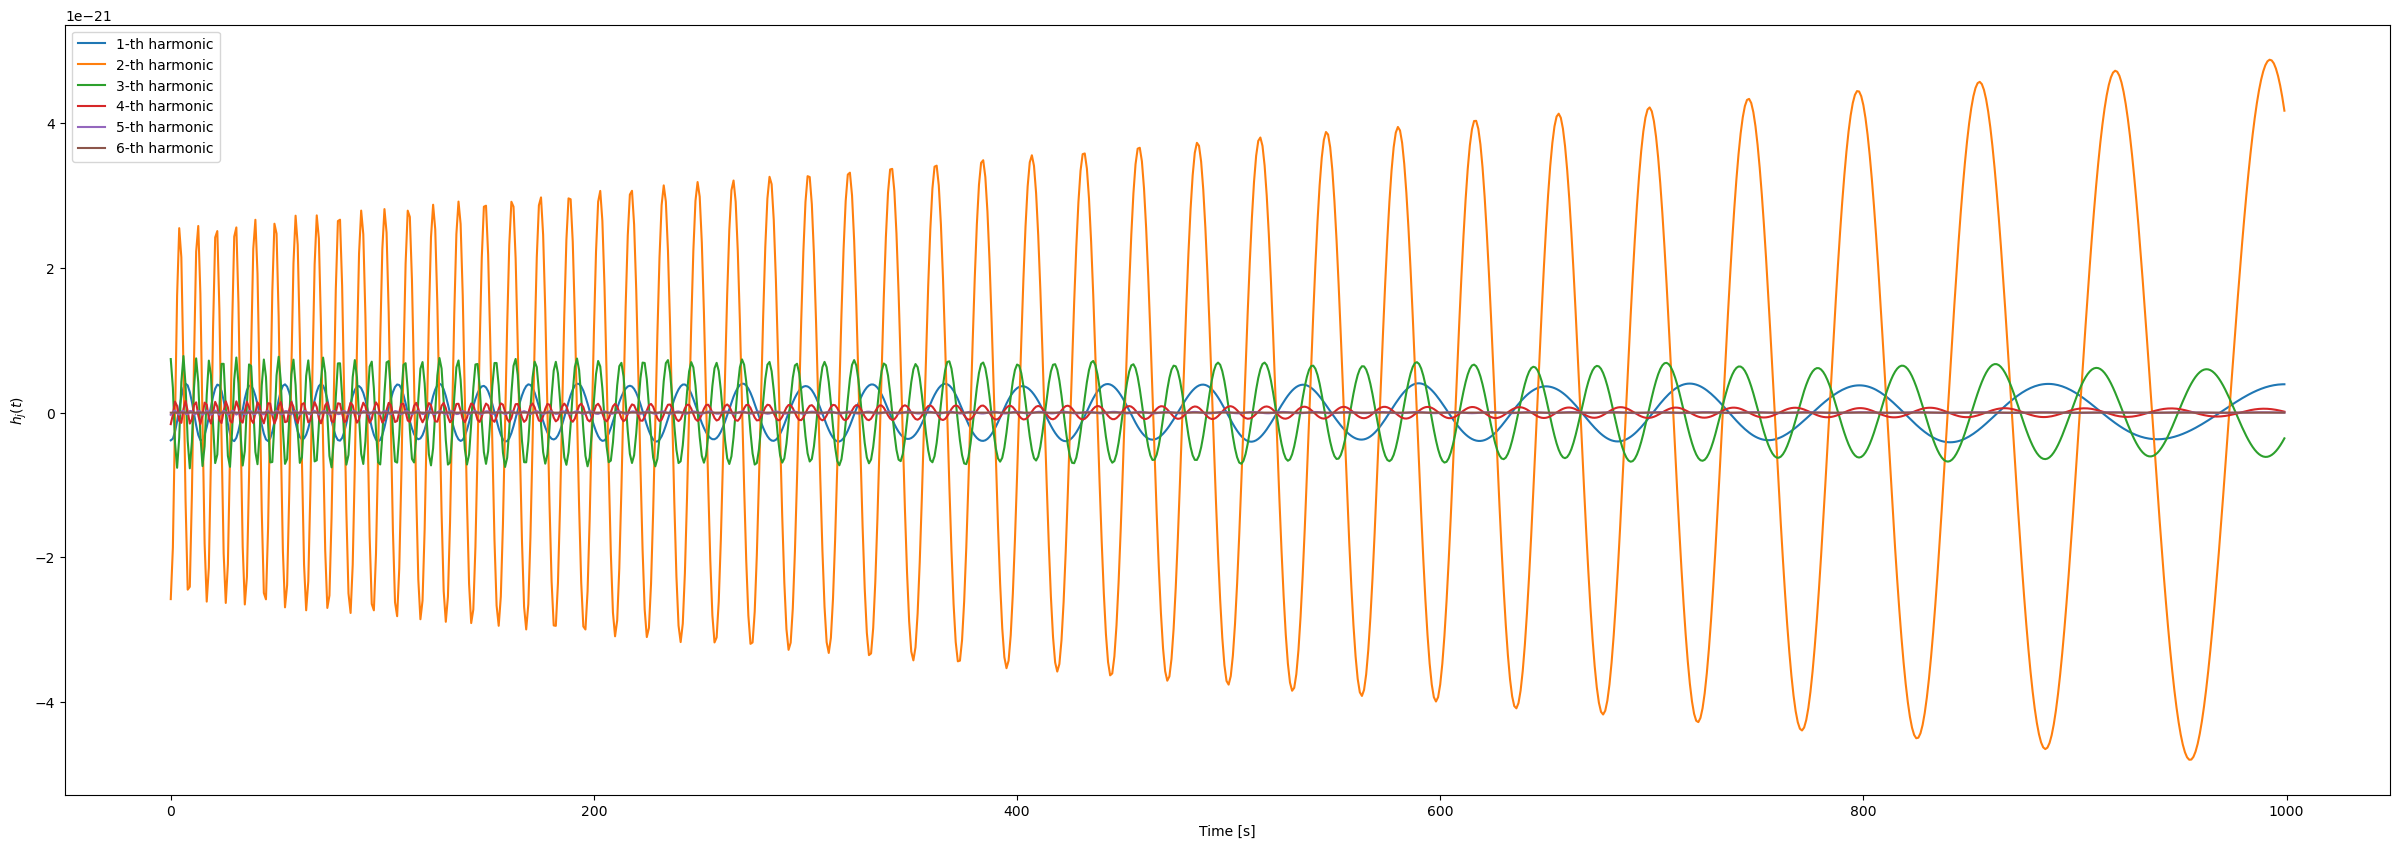

In [55]:
plt.figure(figsize=(30, 10))

for j_index, waveform in sorted_harmonics.items():
        plt.plot(waveform.real, label=f'{j_index}-th harmonic')
plt.ylabel('$h_j(t)$')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

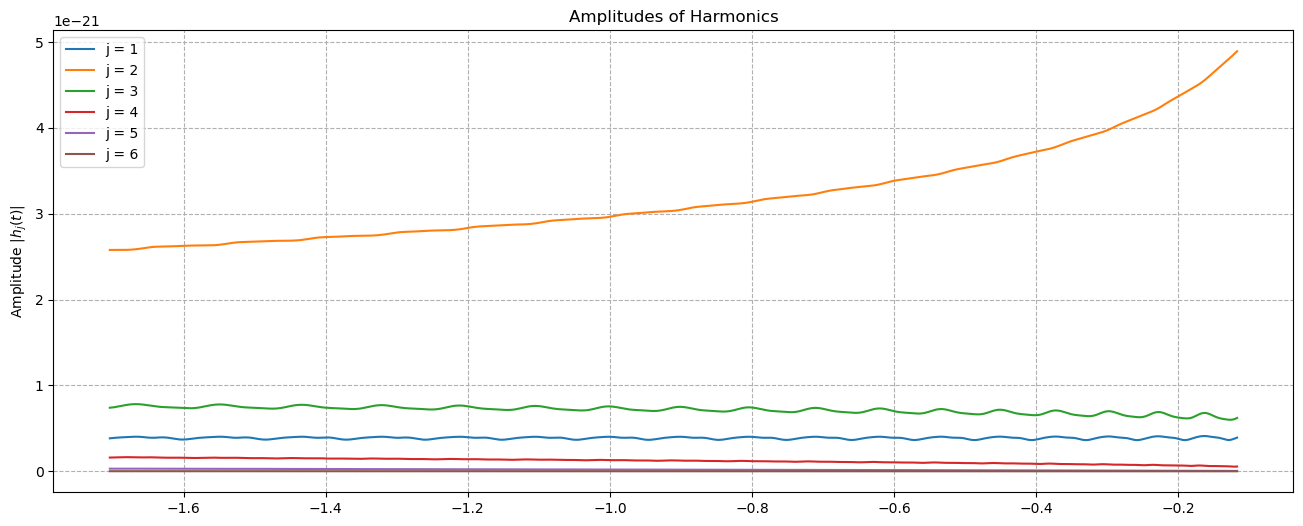

In [57]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    amp = np.abs(waveform)
    plt.plot(t_val, amp, label=f'j = {j_index}')
plt.ylabel('Amplitude |$h_j(t)$|')
plt.title('Amplitudes of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")

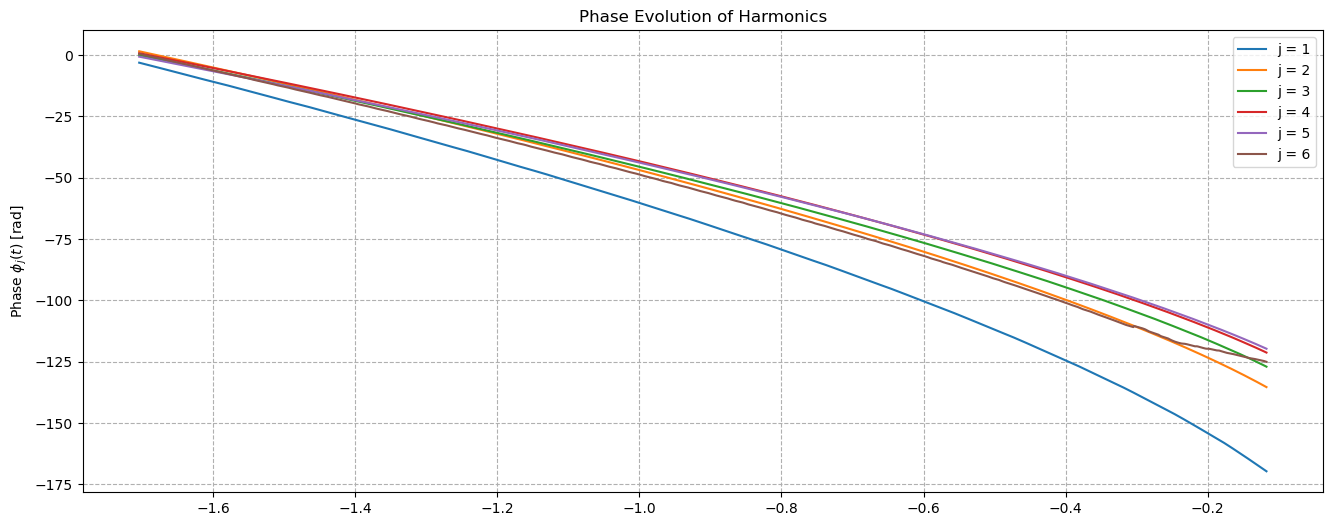

In [58]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    plt.plot(t_val, 1 / j_index * phase, label=f'j = {j_index}')
plt.ylabel('Phase $\phi_j(t)$ [rad]')
plt.title('Phase Evolution of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")


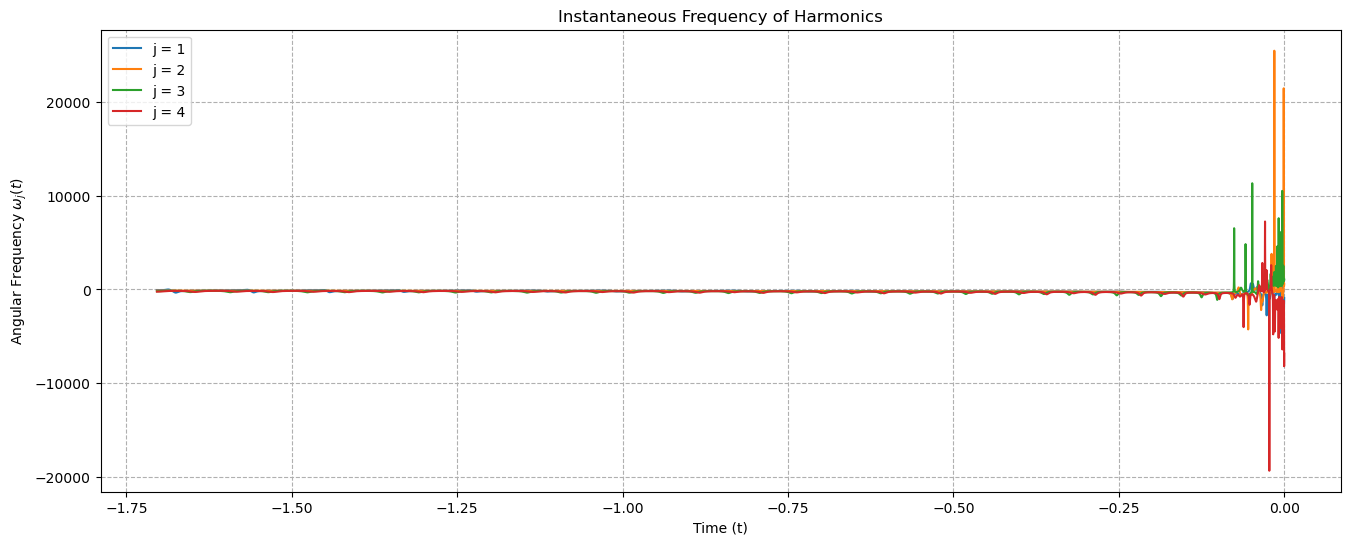

In [42]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    omega = np.gradient(phase, dt)
    plt.plot(ref_time, omega, label=f'j = {j_index}')
plt.ylabel('Angular Frequency $\omega_j(t)$')
plt.title('Instantaneous Frequency of Harmonics')
plt.xlabel('Time (t)')
plt.legend()
plt.grid(True, which="both", ls="--")